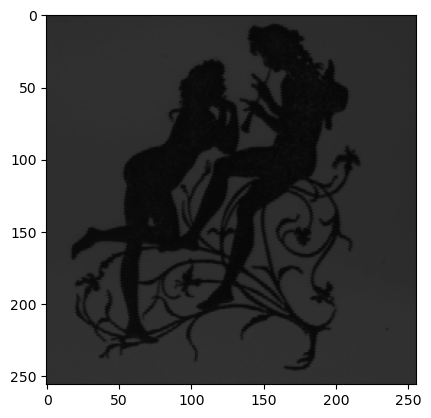

In [15]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/AMOUR.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.show()

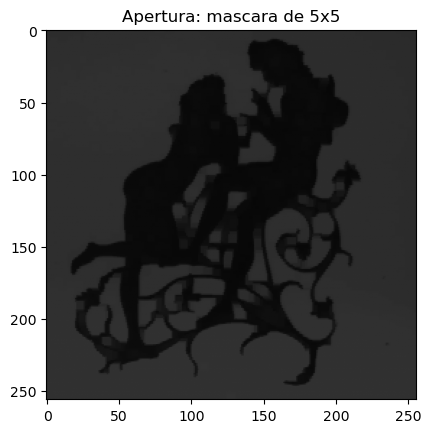

In [16]:
#Realice la operación de apertura usando una máscara cuadrada de tamaño 5x5.
from skimage.morphology import dilation, erosion, opening, closing
import numpy as np

fp = np.array([
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
])

opening_image = opening(image, footprint=fp)

plt.imshow(opening_image, cmap="gray", vmin=0, vmax=255)
plt.title("Apertura: mascara de 5x5")
plt.show()

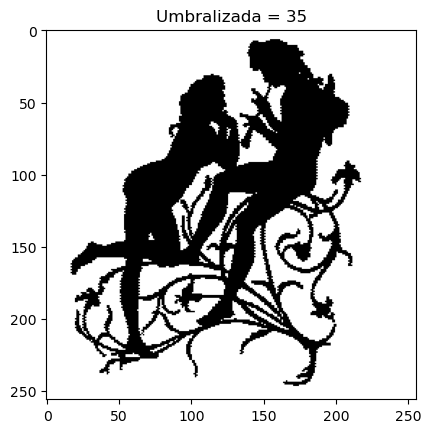

In [17]:
#Retome la imagen original, y aplique una umbralización para binarizarla (umbral = 35).

ret,umbralizada = cv2.threshold(image,35,255,cv2.THRESH_BINARY)

plt.imshow(umbralizada, cmap="gray", vmin=0, vmax=255)
plt.title("Umbralizada = 35")
plt.show()

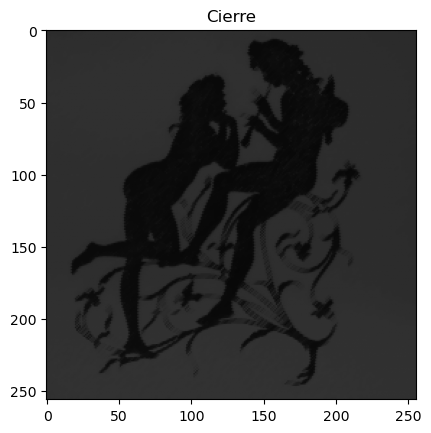

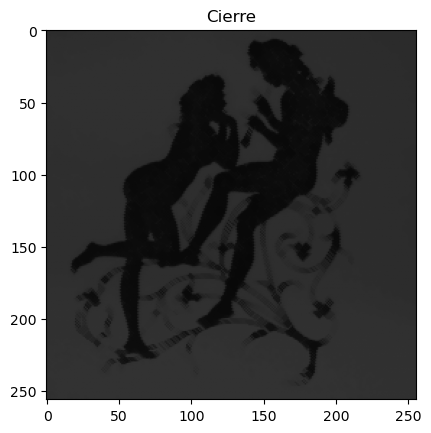

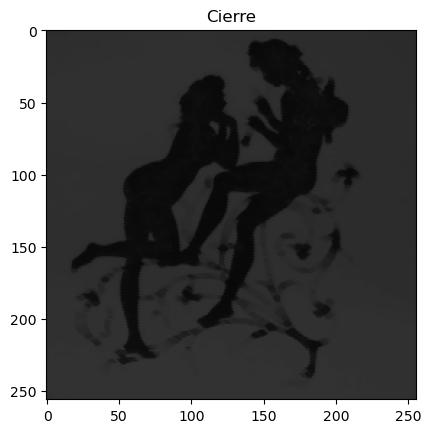

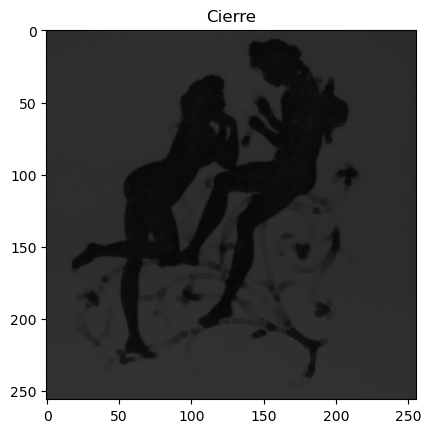

In [ ]:
#Realice el cierre de la imagen. Para esto, efectúe 4 cierres aplicando sucesivamente las 4 máscaras lineales simétricas de tamaño 1x3

fp_diagonal_1 = np.array([
    [0,0,1],
    [0,1,0],
    [1,0,0]
])

fp_diagonal_2 = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

fp_horizontal = np.array([
    [1,1,1]
])

fp_vertical = np.array([
    [1],
    [1],
    [1]
])

closing_image1 = closing(image, footprint=fp_diagonal_1)
closing_image2 = closing(closing_image1, footprint=fp_diagonal_2)
closing_image3 = closing(closing_image2, footprint=fp_horizontal)
closing_image4 = closing(closing_image3, footprint=fp_vertical)


plt.imshow(closing_image1, cmap="gray", vmin=0, vmax=255)
plt.title("Cierre 1")
plt.show()

plt.imshow(closing_image2, cmap="gray", vmin=0, vmax=255)
plt.title("Cierre 2")
plt.show()

plt.imshow(closing_image3, cmap="gray", vmin=0, vmax=255)
plt.title("Cierre 3")
plt.show()

plt.imshow(closing_image4, cmap="gray", vmin=0, vmax=255)
plt.title("Cierre 4")
plt.show()



uint8
8
50


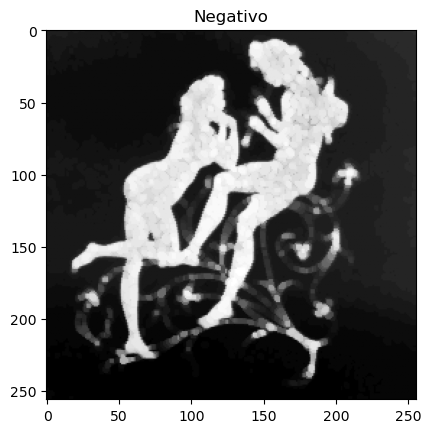

In [29]:
#Tome el negativo de la imagen resultado, de forma tal que las figuras se vuelvan blancas.
print(closing_image4.dtype)
print(closing_image4.min())
print(closing_image4.max())

negativo = cv2.bitwise_not(closing_image4)

plt.imshow(negativo, cmap="gray")
plt.title("Negativo")
plt.show()

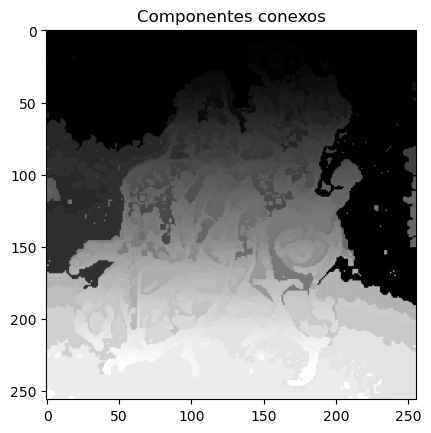

In [35]:
#Seleccione el componente conexo más grande
from skimage.measure import label

connected_components = label(negativo, background=0, connectivity=2)

plt.imshow(connected_components, cmap="gray")
plt.title("Componentes conexos")
plt.show()
